In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import tensorflow as tf
import os, shutil, random
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
base_path = '/content/drive/MyDrive/dataset'

In [ ]:
output_path = '/content/dataset_split'
classes = ['organic', 'recyclable']

for cls in classes:
    img_list = os.listdir(os.path.join(base_path, cls))
    random.shuffle(img_list)

    split_index = int(len(img_list) * 0.8)

    train_imgs = img_list[:split_index]
    test_imgs = img_list[split_index:]

    for folder in ['train', 'test']:
        os.makedirs(os.path.join(output_path, folder, cls), exist_ok=True)

    for img in train_imgs:
        shutil.copy(os.path.join(base_path, cls, img),
                    os.path.join(output_path, 'train', cls, img))

    for img in test_imgs:
        shutil.copy(os.path.join(base_path, cls, img),
                    os.path.join(output_path, 'test', cls, img))

print("Split selesai!")

Split selesai!


In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.3,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    '/content/dataset_split/train',
    target_size=(224,224),
    class_mode='binary'
)

test_gen = test_datagen.flow_from_directory(
    '/content/dataset_split/test',
    target_size=(224,224),
    class_mode='binary',
    shuffle=False
)

Found 19764 images belonging to 2 classes.
Found 4941 images belonging to 2 classes.


In [ ]:
base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs=base_model.input, outputs=output)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_gen,
    validation_data=test_gen,
    epochs=10
)

Epoch 1/10
618/618 ━━━━━━━━━━━━━━━━━━━━ 333s 507ms/step - accuracy: 0.9054 - loss: 0.2376 - val_accuracy: 0.9320 - val_loss: 0.1806
Epoch 2/10
618/618 ━━━━━━━━━━━━━━━━━━━━ 285s 462ms/step - accuracy: 0.9271 - loss: 0.1871 - val_accuracy: 0.9286 - val_loss: 0.1790
Epoch 3/10
618/618 ━━━━━━━━━━━━━━━━━━━━ 300s 486ms/step - accuracy: 0.9328 - loss: 0.1711 - val_accuracy: 0.9354 - val_loss: 0.1729
Epoch 4/10
618/618 ━━━━━━━━━━━━━━━━━━━━ 271s 438ms/step - accuracy: 0.9383 - loss: 0.1575 - val_accuracy: 0.9389 - val_loss: 0.1615
Epoch 5/10
618/618 ━━━━━━━━━━━━━━━━━━━━ 261s 422ms/step - accuracy: 0.9393 - loss: 0.1572 - val_accuracy: 0.9371 - val_loss: 0.1578
Epoch 6/10
618/618 ━━━━━━━━━━━━━━━━━━━━ 261s 423ms/step - accuracy: 0.9440 - loss: 0.1480 - val_accuracy: 0.9411 - val_loss: 0.1569
Epoch 7/10
618/618 ━━━━━━━━━━━━━━━━━━━━ 262s 425ms/step - accuracy: 0.9451 - loss: 0.1438 - val_accuracy: 0.9358 - val_loss: 0.1643
Epoch 8/10
618/618 ━━━━━━━━━━━━━━━━━━━━ 262s 423ms/step - accuracy: 0.9491 -

In [ ]:
print("TRAIN ACC:", history.history['accuracy'][-1])
print("TEST ACC :", history.history['val_accuracy'][-1])


TRAIN ACC: 0.9516798257827759
TEST ACC : 0.942319393157959


In [ ]:
# TEST
test_gen.reset()
pred_test = model.predict(test_gen)
y_pred_test = (pred_test > 0.5).astype(int).reshape(-1)
y_true_test = test_gen.classes

# TRAIN
train_gen.reset()
pred_train = model.predict(train_gen)
y_pred_train = (pred_train > 0.5).astype(int).reshape(-1)
y_true_train = train_gen.classes

155/155 ━━━━━━━━━━━━━━━━━━━━ 19s 80ms/step
618/618 ━━━━━━━━━━━━━━━━━━━━ 257s 415ms/step


In [ ]:
print("\n===== TESTING REPORT =====")
print(classification_report(y_true_test, y_pred_test, target_names=['organic','recyclable']))

print("\n===== TRAINING REPORT =====")
print(classification_report(y_true_train, y_pred_train, target_names=['organic','recyclable']))


===== TESTING REPORT =====
              precision    recall  f1-score   support

     organic       0.96      0.94      0.95      2776
  recyclable       0.92      0.95      0.94      2165

    accuracy                           0.94      4941
   macro avg       0.94      0.94      0.94      4941
weighted avg       0.94      0.94      0.94      4941


===== TRAINING REPORT =====
              precision    recall  f1-score   support

     organic       0.56      0.56      0.56     11104
  recyclable       0.44      0.44      0.44      8660

    accuracy                           0.51     19764
   macro avg       0.50      0.50      0.50     19764
weighted avg       0.51      0.51      0.51     19764



In [ ]:
cm = confusion_matrix(y_true_test, y_pred_test)
print("\nConfusion Matrix:\n", cm)


Confusion Matrix:
 [[2602  174]
 [ 111 2054]]


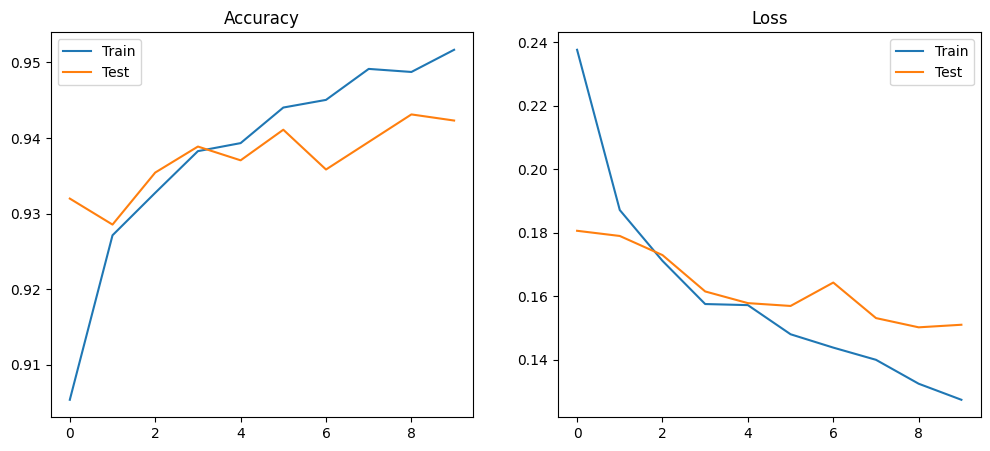

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy')
plt.legend(['Train','Test'])

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss')
plt.legend(['Train','Test'])

plt.show()

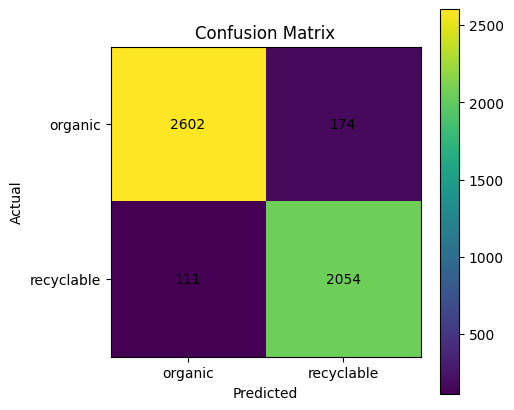

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,5))
plt.imshow(cm)

plt.title("Confusion Matrix")
plt.colorbar()

classes = ['organic', 'recyclable']
plt.xticks(range(len(classes)), classes)
plt.yticks(range(len(classes)), classes)

# isi angka di kotak
for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(j, i, cm[i][j],
                 ha='center', va='center',
                 color='black')

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

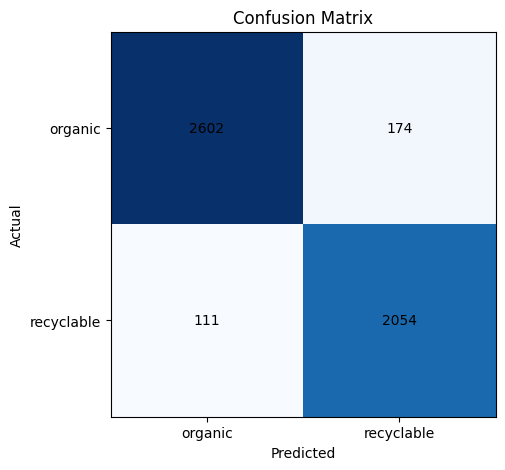

In [ ]:
plt.figure(figsize=(5,5))
plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix")

classes = ['organic','recyclable']
plt.xticks(range(2), classes)
plt.yticks(range(2), classes)

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i][j], ha='center', va='center')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
model.save('/content/drive/MyDrive/mobilenetv2_sampah.h5')